# Configurações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
home = os.getcwd()
diretorio_projeto = home
os.chdir(diretorio_projeto)

if diretorio_projeto not in sys.path:
    sys.path.append(diretorio_projeto)

from visualisation import plotar_metricas_cv, plotar_loss_cv, imprimir_metricas_finais


In [ ]:

def compilar_estatisticas_cv(caminho_raiz, nome_logger="cv_resultados", num_folds=10):
    lista_dfs = []

    for i in range(1, num_folds + 1):
        caminho_csv = f"{caminho_raiz}/{nome_logger}/fold_{i}/metrics.csv"

        if os.path.exists(caminho_csv):
            df_fold = pd.read_csv(caminho_csv)
            df_fold_limpo = df_fold.groupby('epoch').mean().reset_index()
            lista_dfs.append(df_fold_limpo)
        else:
            print(f"Aviso: Log do fold_{i} não encontrado.")

    if not lista_dfs:
        raise ValueError("Nenhum arquivo de log encontrado.")

    df_completo = pd.concat(lista_dfs)

    df_stats = df_completo.groupby('epoch').agg(['mean', 'std'])
    df_stats.columns = ['_'.join(col).strip() for col in df_stats.columns.values]
    df_stats = df_stats.reset_index()

    return df_stats


In [ ]:

diretorio_logs = f"{diretorio_projeto}/logs"

# Análise do modelo

# Resultados



## Baseline


In [4]:
df_resultados= compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados")

Resultados do modelo baseline:
Relatório - 10 Folds
AUROC            : 0.4999 ± 0.0005
F1-Score         : 0.0000 ± 0.0000


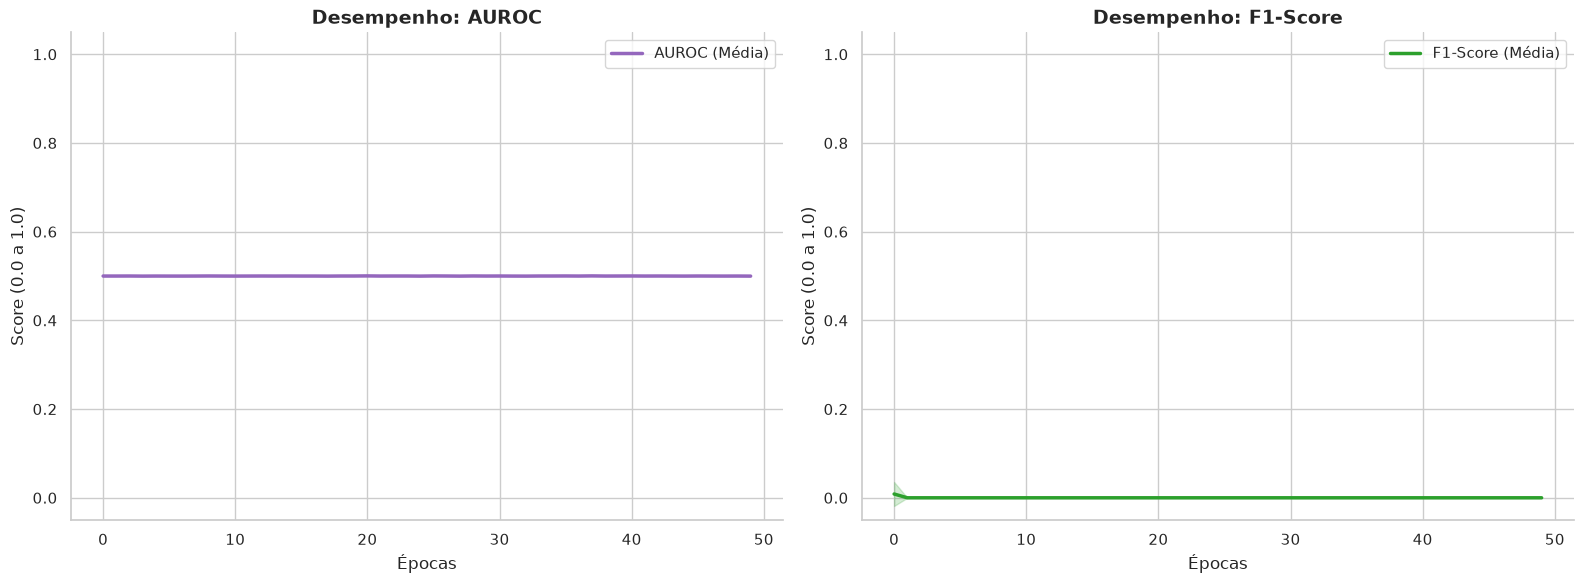

In [5]:
print("Resultados do modelo baseline:")
imprimir_metricas_finais(df_resultados)
plotar_metricas_cv(df_resultados)

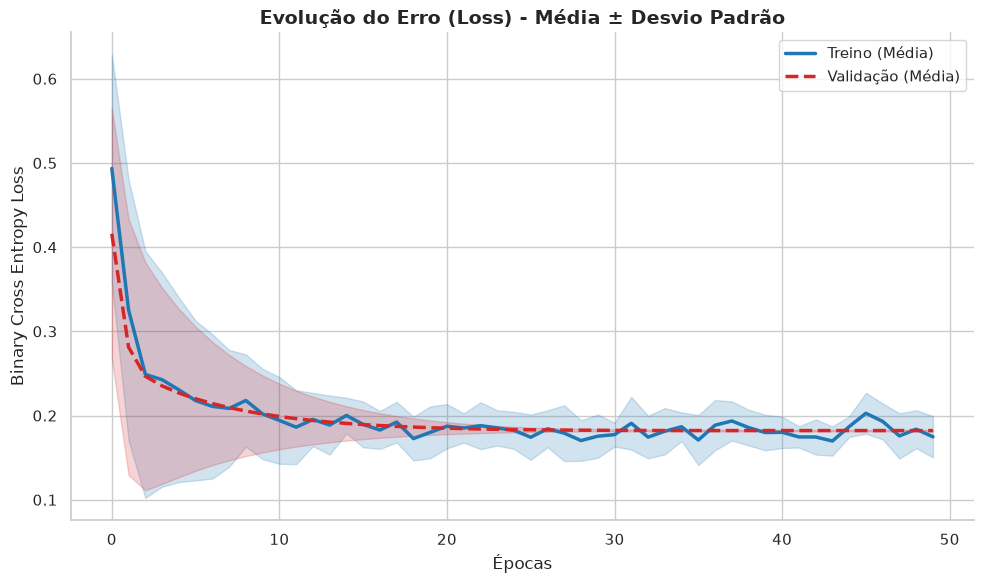

In [6]:
plotar_loss_cv(df_resultados)

Essas mudanças abruptas e loss alta podem indicar que nossa learning rate está muito alta, alem disso podemos ver que a partir da epoca 27 o modelo começa a sofrer um overfitting, com a loss do treino descendo enquanto a loss de validação aumenta.

Alem disso, para a v2 vamos adicionar class weighting para tentar melhorar o f1 score.

## modelo V2

In [7]:
df_resultados_v2 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v2")


Resultados do modelo v2:
Relatório - 10 Folds
AUROC            : 0.5000 ± 0.0000
F1-Score         : 0.0000 ± 0.0000


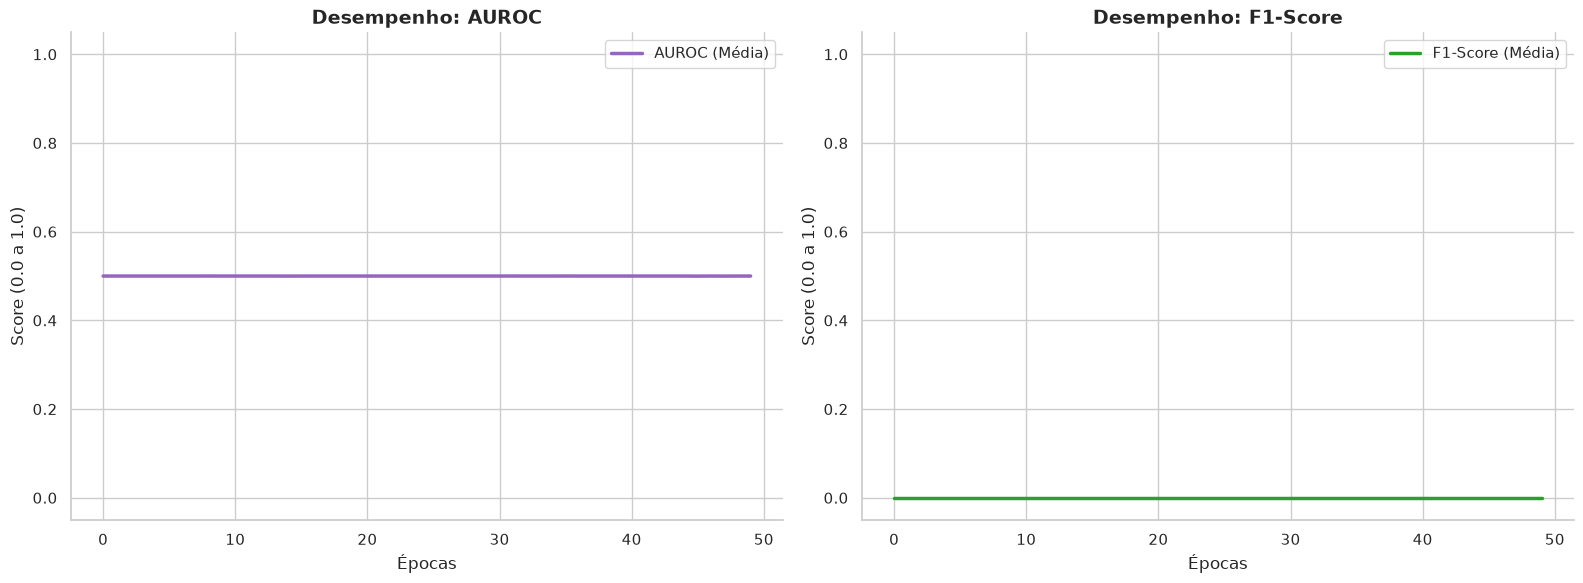

In [8]:
print("\nResultados do modelo v2:")
imprimir_metricas_finais(df_resultados_v2)
plotar_metricas_cv(df_resultados_v2)

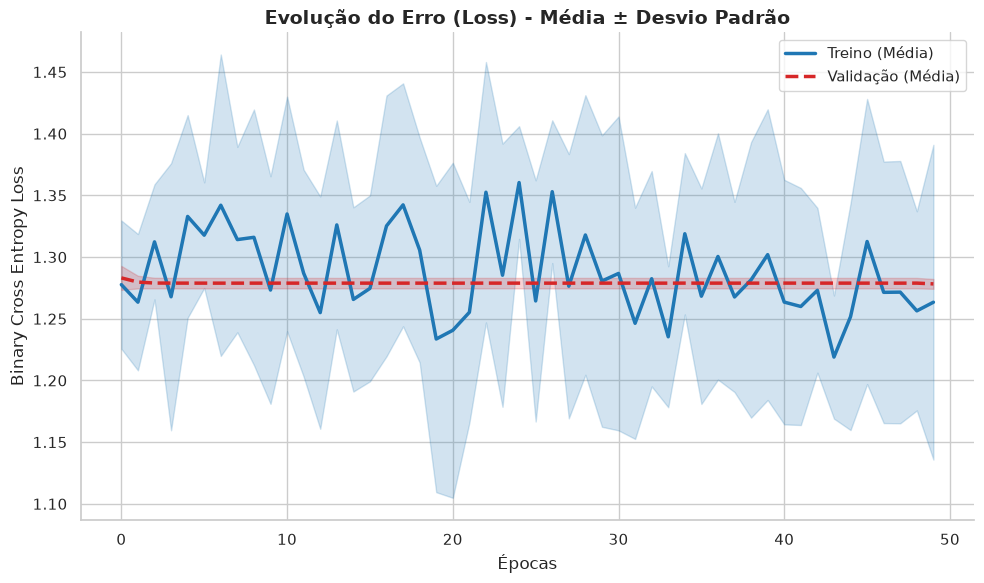

In [9]:
plotar_loss_cv(df_resultados_v2)

Parece que as mudanças não ajudaram muito, eu vou avaliar algumas arquiteturas com um breve sweep e adicionar uma regularização.

In [ ]:

diretorio_output = f"{diretorio_projeto}/output"
sweep_df = pd.read_csv(f"{diretorio_output}/capacity_sweep_resultados.csv")

In [11]:
sweep_df = sweep_df.sort_values(by='val_loss', ascending=True)
sweep_df

,n_hidden,n_neurons,total_params,trainable_params,val_loss,val_auroc,val_f1
0,1,32,2273,2273,0.530682,0.936269,0.331990
4,3,16,1425,1425,0.532419,0.935234,0.328335
1,2,16,1153,1153,0.534408,0.935449,0.326954
2,3,32,4385,4385,0.535186,0.935348,0.326275
7,4,16,1697,1697,0.541165,0.933809,0.317757
9,1,16,881,881,0.541865,0.933670,0.327156
3,0,32,1217,1217,0.543083,0.935310,0.341995
5,0,64,2433,2433,0.543759,0.934906,0.338333
8,0,128,4865,4865,0.547006,0.933703,0.339781
10,2,32,3329,3329,0.548796,0.933193,0.330379


Até um momento estavamos utilizando n_hidden = 3 e n_neurons = 32, vamos reduzir o número de camadas ocultas e utilizar dropout para proxima iteração, tambem vou deixar a taxa de aprendizado fixa, ja que ela parece não ter ajudado na ultima iteração.

## Modelo V3


Aviso: Log do fold_10 não encontrado.

Resultados do modelo v3:
Relatório - 10 Folds
AUROC            : 0.9353 ± 0.0048
F1-Score         : 0.3249 ± 0.0049


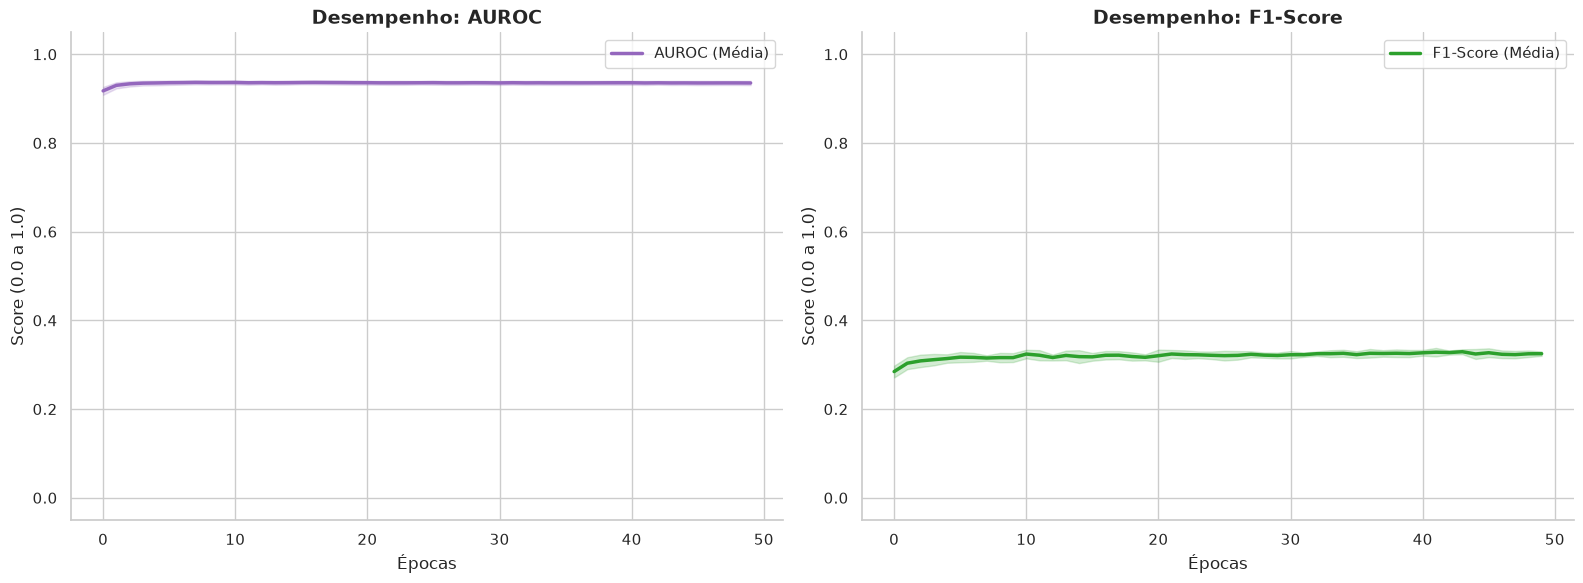

In [12]:
df_resultados_v3 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v3")
print("\nResultados do modelo v3:")
imprimir_metricas_finais(df_resultados_v3)
plotar_metricas_cv(df_resultados_v3)

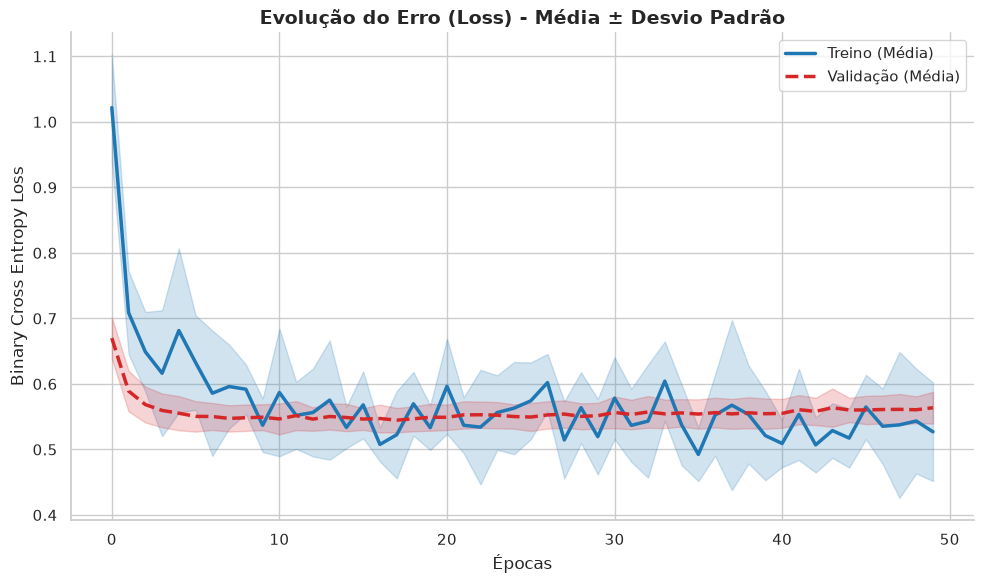

In [13]:
plotar_loss_cv(df_resultados_v3)

Agora que melhoramos um pouco o overfitting, vamos tentar melhorar o f1 treinando o limiar de decisão.


Alem disso vou começar a monitorar outras métricas

In [14]:
sweep_df = pd.read_csv(f"{diretorio_output}/pos_weight_sweep_resultados.csv")
sweep_df = sweep_df.sort_values(by='val_loss', ascending=True)
sweep_df

,pos_weight,dropout,val_loss,val_auroc,val_f1
2,5.0,0.5,0.282148,0.936061,0.426396
12,5.0,0.3,0.290456,0.933302,0.407876
13,5.0,0.1,0.290894,0.932781,0.410397
1,10.0,0.5,0.393075,0.937101,0.372719
11,10.0,0.1,0.405969,0.933325,0.379098
10,10.0,0.3,0.408182,0.933468,0.359023
0,15.0,0.5,0.470286,0.937586,0.334707
7,15.0,0.3,0.484235,0.934968,0.352423
9,15.0,0.1,0.487737,0.934097,0.341297
3,20.0,0.3,0.546876,0.935381,0.313124


Nosso F1 ainda está ruim, vamos procurar um peso melhor para a a classe positiva. Vou aproveitar para testar se o dropout está em um valor bom.

## Modelo V4


In [15]:
df_resultados_v4 = compilar_estatisticas_cv(caminho_raiz=diretorio_logs,nome_logger="cv_resultados_v4")

Aviso: Log do fold_10 não encontrado.


In [16]:
from visualisation import imprimir_metricas_finais_v4
print("\nResultados do modelo v4:")
imprimir_metricas_finais_v4(df_resultados_v4)


Resultados do modelo v4:
Relatório - 10 Folds
AUROC                         : 0.9345 ± 0.0049
Average Precision             : 0.3294 ± 0.0197
F1-Score (Threshold 0.5)      : 0.4189 ± 0.0158
F1-Score Otimizado            : 0.4273 ± 0.0121
Precision                     : 0.3239 ± 0.0198
Recall                        : 0.6400 ± 0.0807
Specificity                   : 0.9369 ± 0.0119
Accuracy                      : 0.9236 ± 0.0080
Balanced Accuracy             : 0.7884 ± 0.0347
Melhor Threshold              : 0.5633 ± 0.0609


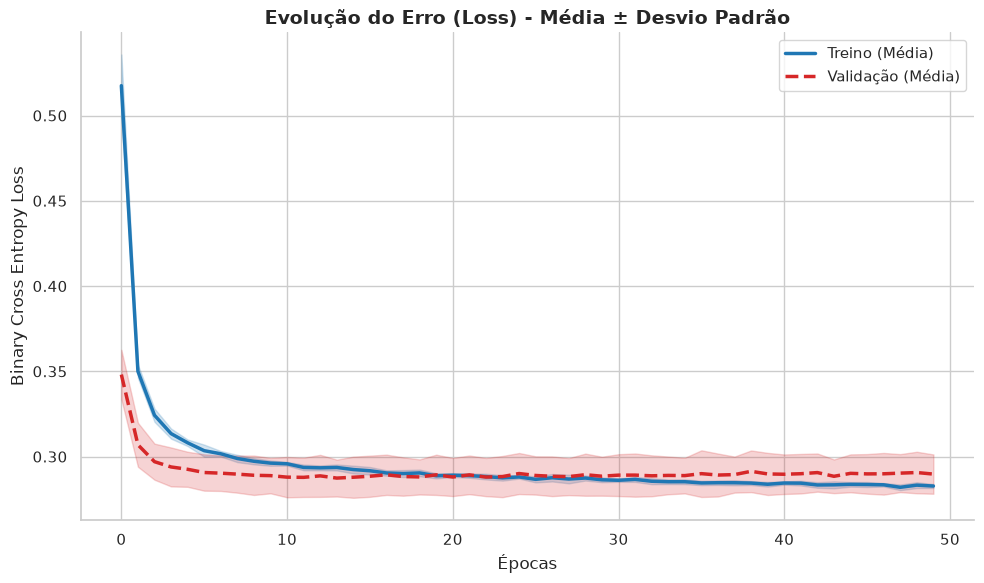

In [17]:
plotar_loss_cv(df_resultados_v4)